<a href="https://colab.research.google.com/github/JBlankenship1/MachineLearningProjects/blob/main/dimensionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [ ]:
#Get the breast cancer dataset
from sklearn import datasets
breast_db = datasets.load_breast_cancer()
breast_db.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
print(breast_db['DESCR'])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [ ]:
breast_Xhd = breast_db['data']
labels = breast_db['target']
breast_Xhd.shape

(569, 30)

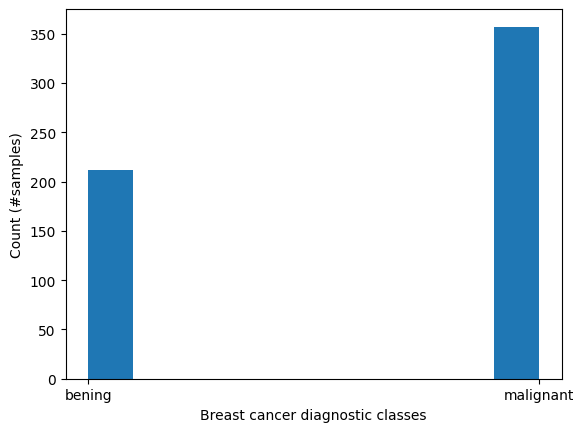

In [ ]:
#label distribution
plt.hist(labels)
plt.xlabel('Breast cancer diagnostic classes')
plt.xticks([0, 1], ['bening', 'malignant'])
plt.ylabel('Count (#samples)');

In [ ]:
#Classification model with the original data dimensionality
from sklearn.model_selection import train_test_split
'''Split the dataset'''
X_train, X_test, y_train, y_test = train_test_split(breast_Xhd,
                                                    labels, test_size=0.25)


from sklearn.neighbors import KNeighborsClassifier

'''KNN Classification'''
#get the model
KN_model = KNeighborsClassifier()

#fit to the train data
KN_model.fit(X_train, y_train)

#predict labels for the test data
KN_prediction = KN_model.predict(X_test)


from sklearn import metrics

#check overall accuracy and (10x10) confusion matrix
print('Accuracy: ', metrics.accuracy_score(KN_prediction, y_test).round(2),
      'Confusion matrix:\n', metrics.confusion_matrix(KN_prediction, y_test))

Accuracy:  0.93 Confusion matrix:
 [[47  2]
 [ 8 86]]


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#scale the data first
scaler = StandardScaler()
breast_Xhd_scaled = scaler.fit_transform(breast_Xhd)

#n_components-->Number of principal components, vary it to see the effect
pca = PCA(n_components=5)

breast_Xld = pca.fit_transform(breast_Xhd_scaled)
breast_Xld.shape

(569, 5)

Text(0, 0.5, 'pca1')

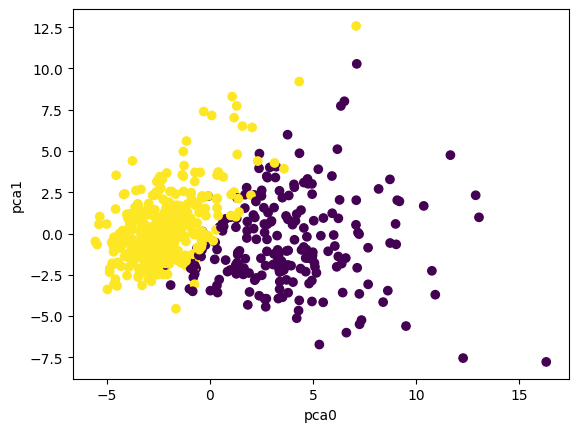

In [ ]:
plt.scatter(breast_Xld[:,0], breast_Xld[:,1], c=labels)
pca_feature_names = pca.get_feature_names_out()
plt.xlabel(pca_feature_names[0])
plt.ylabel(pca_feature_names[1])

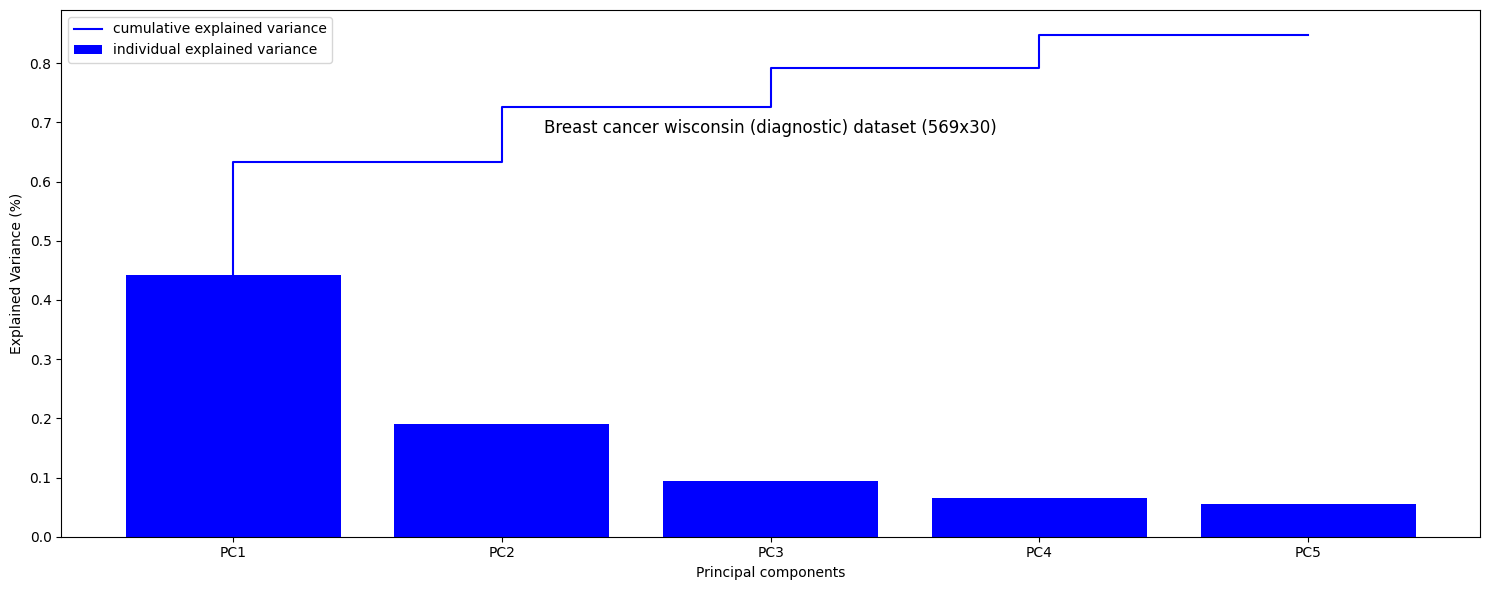

In [ ]:
#Percentage of explained variance
plt.figure(figsize=(15,6))

expl_var_rat = pca.explained_variance_ratio_
plt.bar(range(1,len(expl_var_rat)+1), expl_var_rat, color='b', align='center',
        label='individual explained variance')

plt.step(range(1,6), np.cumsum(pca.explained_variance_ratio_), color='b',
         label='cumulative explained variance')

plt.xticks(range(1,len(expl_var_rat)+1),
 ['PC'+str(i) for i in range(1,len(expl_var_rat)+1)])
plt.xlabel('Principal components')
plt.ylabel('Explained Variance (%)')
plt.title('Breast cancer wisconsin (diagnostic) dataset (569x30)', y=0.75)
plt.legend(loc='best')
plt.tight_layout();

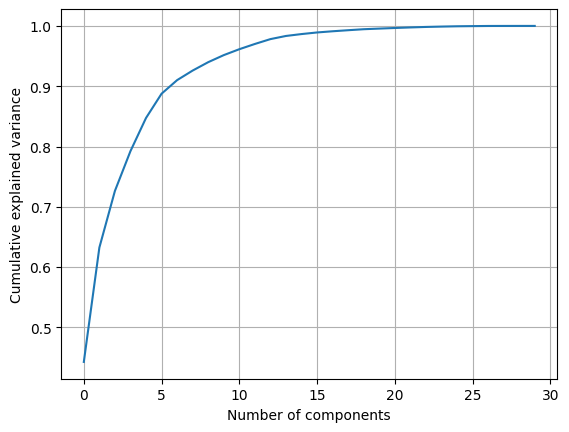

In [ ]:
#Choosing the number of components
pca = PCA().fit(breast_Xhd_scaled)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.grid()
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance');

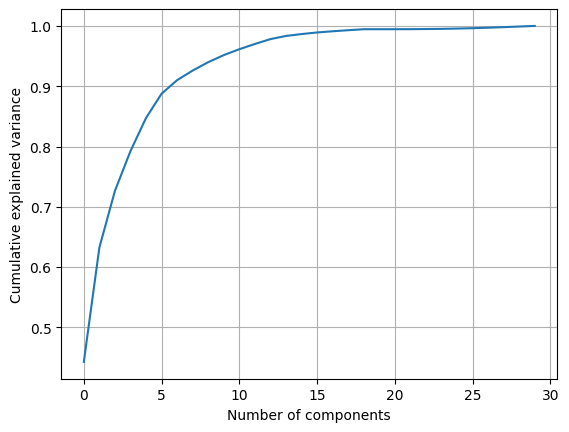

In [ ]:
#Principal Components using numpy
cov = np.cov(breast_Xhd_scaled.T)
eval, evec = np.linalg.eig(cov)
eval_rat = [i/eval.sum() for i in eval]
plt.plot(np.cumsum(eval_rat))
plt.grid()
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance');

In [ ]:
#Classification model with the lower (PCA) data dimensionality
'''Split the dataset'''
X_train, X_test, y_train, y_test = train_test_split(breast_Xld,
                                                    labels, test_size=0.25)

'''KNN Classification'''
#get the model
KN_model = KNeighborsClassifier()

#fit to the train data
KN_model.fit(X_train, y_train)

#predict labels for the test data
KN_prediction = KN_model.predict(X_test)


#check overall accuracy and (2x2) confusion matrix
print('Accuracy: ', metrics.accuracy_score(KN_prediction, y_test).round(2),
      'Confusion matrix:\n', metrics.confusion_matrix(KN_prediction, y_test))

Accuracy:  0.97 Confusion matrix:
 [[42  2]
 [ 3 96]]


## **Image Recognition: Data Preparation, Dimensionality reduction/feature extraction, Machine Learning Algorithms & Evaluation**


#### Several small datasets are already available in scikit-learn datsets package. Here, we use the hand-written digit recognition dataset. The dataset comes with $8\times8$ digit images and target class labels, all in a dictionary.   

#### To Do:
<ul>Load the digit dataset from scikit-learn datasets</ul>
<ul>Get the images and corresponding class labels</ul>
<ul>Verify the shape of the images and labels</ul>


## Read the data

---


#### Understand it: check, analyze, visualize

In [ ]:
digit_data = datasets.load_digits() #n_class: number of digit classes
digit_data.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [ ]:
'''Extract the 'images' and 'target' from the dictionary'''
images = digit_data['images']
labels = digit_data['target']

images.shape, labels.shape

((1797, 8, 8), (1797,))

(-0.5, 7.5, 7.5, -0.5)

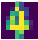

In [ ]:
#Visualize some random images and their corresponding labels
img_id = 400
plt.figure(dpi=10)
plt.imshow(images[img_id])
plt.title('Class: '+str(labels[img_id]))
plt.axis('off')

## Feature Extraction

---
Remember how we extracted features: using just the pixel intensity values as a vector

<ul>Reshape the 2D images to obtain n-number of 1D samples</ul>
<ul>Verify the shape</ul>

Let's reduce dimension from 64 to 2 using PCA.

You can get the PCA implementation in scikit-learn decomposition package.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2) #n_components-->Number of principal components, vary it to see the effect

images_ld = pca.fit_transform(images.reshape(-1,8*8))
images_ld.shape

(1797, 2)

### Visualize the results

Text(0, 0.5, 'pca1')

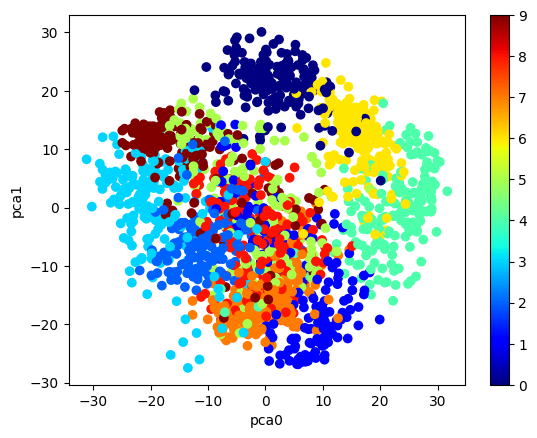

In [ ]:
plt.scatter(images_ld[:,0], images_ld[:,1], c=labels, cmap='jet')
plt.colorbar()
pca_feature_names = pca.get_feature_names_out()
plt.xlabel(pca_feature_names[0])
plt.ylabel(pca_feature_names[1])

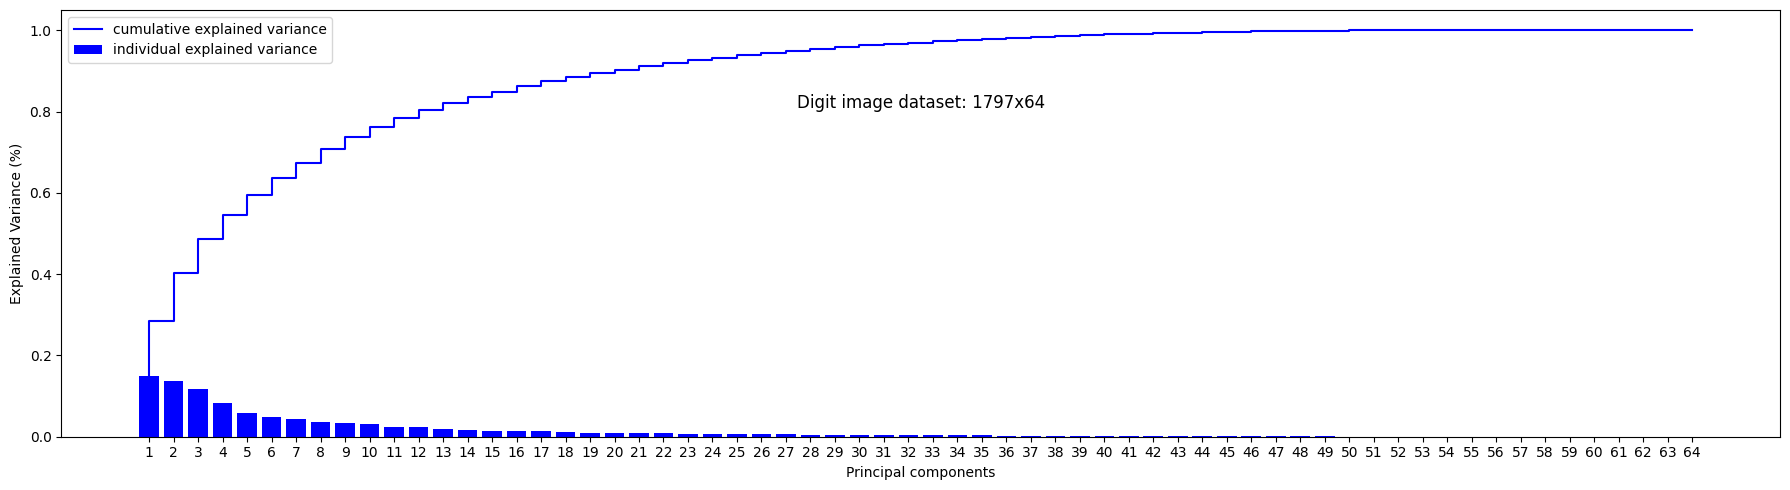

In [ ]:
#Percentage of explained variance
plt.figure(figsize=(18,5))

expl_var_rat = pca.explained_variance_ratio_
plt.bar(range(1,len(expl_var_rat)+1), expl_var_rat, color='b', align='center',
        label='individual explained variance')

plt.step(range(1,65), np.cumsum(pca.explained_variance_ratio_), color='b',
         label='cumulative explained variance')

plt.xticks(range(1,len(expl_var_rat)+1),
 [str(i) for i in range(1,len(expl_var_rat)+1)])
plt.xlabel('Principal components')
plt.ylabel('Explained Variance (%)')
plt.title('Digit image dataset: 1797x64', y=0.75)
plt.legend(loc='best')
plt.tight_layout();

# Classification

Now, let's use a classifier K-Nearest Neighbor algorithm to perform classification on the features (reduced dimension by PCA).

In [ ]:
from sklearn.model_selection import train_test_split
'''Split the dataset'''
X_train, X_test, y_train, y_test = train_test_split(images_ld,
                                                    labels, test_size=0.25)


from sklearn.neighbors import KNeighborsClassifier

'''KNN Classification'''
#get the model
KN_model = KNeighborsClassifier()

#fit to the train data
KN_model.fit(X_train, y_train)

#predict labels for the test data
KN_prediction = KN_model.predict(X_test)


from sklearn import metrics

#check overall accuracy and (10x10) confusion matrix
print('Accuracy: ', metrics.accuracy_score(KN_prediction, y_test).round(2),
      'Confusion matrix:\n', metrics.confusion_matrix(KN_prediction, y_test))

Accuracy:  0.61 Confusion matrix:
 [[34  0  0  0  0  3  5  0  0  0]
 [ 0 26  1  0  1  8  1  3  9  2]
 [ 0  1 31  3  0  3  0  1  7  1]
 [ 0  0  7 33  0  0  0  1  0  7]
 [ 0  1  0  0 38  0  6  1  0  0]
 [ 4  1  4  3  0 16  0  6  9 12]
 [ 1  0  0  0  3  2 25  0  0  0]
 [ 0  7  0  0  0  5  0 31  4  0]
 [ 0 10  8  0  0  5  0  4 15  6]
 [ 0  0  1  4  0  3  0  1  2 24]]


So, just with 2-dimensional features, the KNN model can reach over 60% accuracy. This also shows the most discriminative 2 components (read features) resulted from PCA.

Now,
Repeat the above cells by changing (increasing) the number of principal components and see if the KNN classification performance is improved.

# MR Image Compression and Reconstruction using PCA

Remember the brain MRI we used in our earlier practice. You can get the image from the nibabel package.

MRI image shape:  (128, 96, 24)


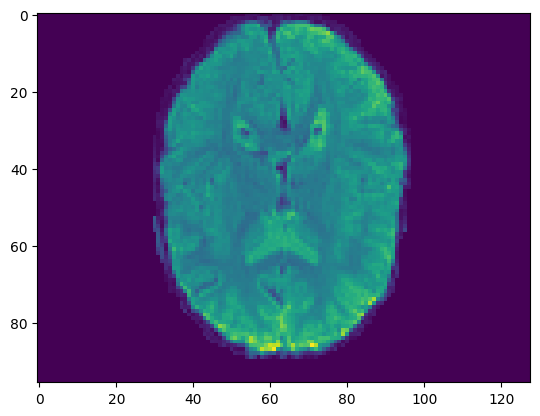

In [ ]:
#Load a nii image and visualize it

import nibabel as nib
from nibabel.testing import data_path

#Load a nifti image from the data_path
img_fname = os.path.join(data_path, 'example4d.nii.gz')
img_nii = nib.load(img_fname)

#numpy array
img_3d = img_nii.get_fdata()[:,:,:,0]
print('MRI image shape: ', img_3d.shape)

#Visualize the middle slice
plt.imshow(img_3d[:,:,12].T)

Here, we have 3D image of $128\times96\times24$ dimension where each slice is of $128\times 96$. If we directly use this high dimensional input ($128*96*24$) to a ML model, it is not feasible (computation, time, space).

We can use PCA for reducing dimensions and use the resultant features as input to our ML model. First, let's see how PCA can compress the slices from this 3D image.

(24, 96, 128)


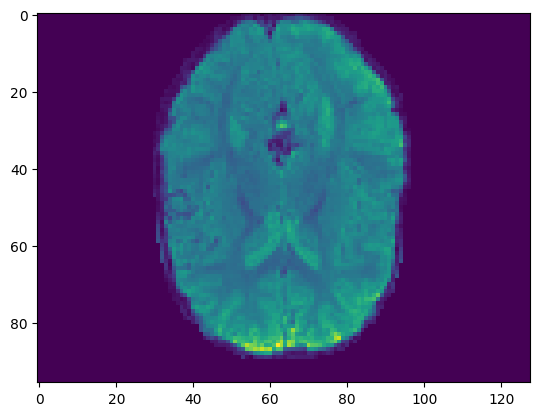

In [ ]:
#Translate the 3D image
img_3d = img_3d.transpose(2,1,0)
print(img_3d.shape)
plt.imshow(img_3d[10])

In [ ]:
#Now apply PCA to compress a slice

pca = PCA(n_components=16) #set the principal components to 16
img_com = pca.fit_transform(img_3d[10]) #input dimension should be <=2
img_com.shape

(96, 16)

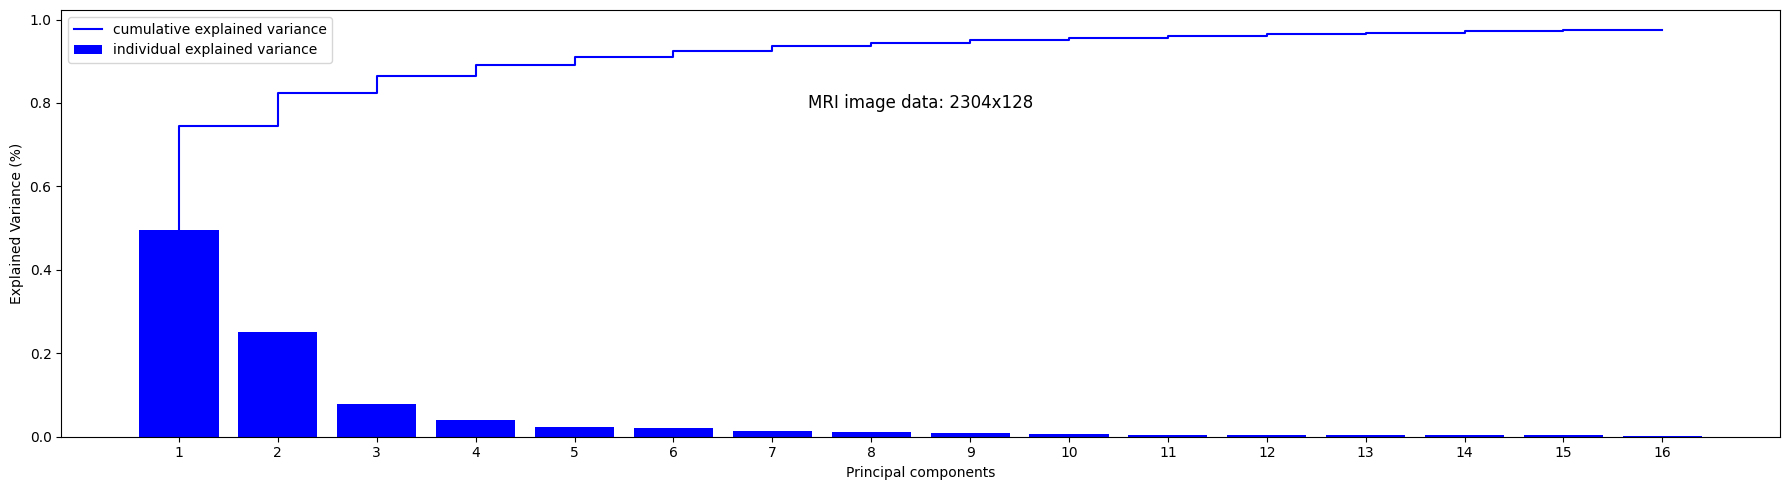

In [ ]:
#Percentage of explained variance
plt.figure(figsize=(18,5))

expl_var_rat = pca.explained_variance_ratio_
plt.bar(range(1,len(expl_var_rat)+1), expl_var_rat, color='b', align='center',
        label='individual explained variance')

plt.step(range(1,17), np.cumsum(pca.explained_variance_ratio_), color='b',
         label='cumulative explained variance')

plt.xticks(range(1,len(expl_var_rat)+1),
 [str(i) for i in range(1,len(expl_var_rat)+1)])
plt.xlabel('Principal components')
plt.ylabel('Explained Variance (%)')
plt.title('MRI image data: 2304x128', y=0.75)
plt.legend(loc='best')
plt.tight_layout();

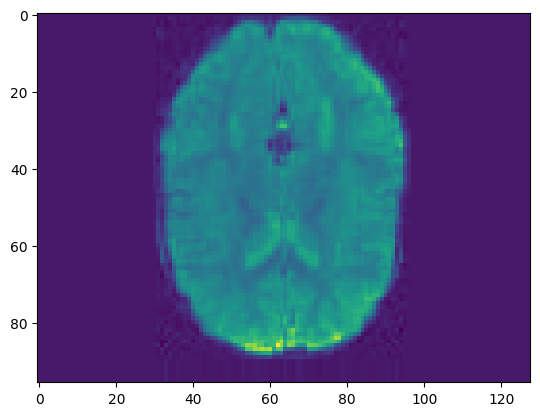

In [ ]:
#Let's do the reconstruction and see how close it is visually to the original
img_recon = pca.inverse_transform(img_com)
plt.imshow(img_recon)

MSE:  533.1832722096615


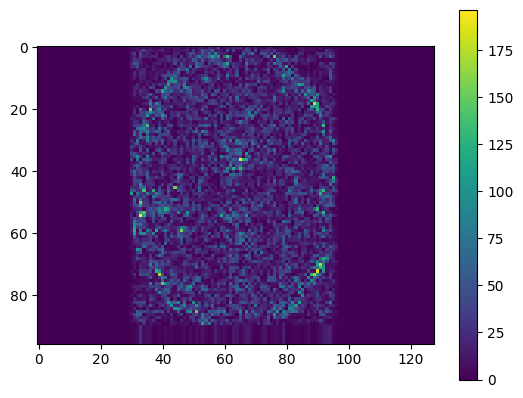

In [ ]:
#Error visualization
print('MSE: ', np.mean((img_3d[10]-img_recon)**2))

plt.imshow(np.abs(img_3d[10]-img_recon))
plt.colorbar()

In [ ]:
#Now, let's try to do it with the whole 3D volume

#Apply PCA to compress all the slices

pca = PCA(n_components=16) #set the principal components to 16
img_3dcom = pca.fit_transform(img_3d.reshape(-1, 96*128)) #input dimension should be <=2
img_3dcom.shape

(24, 16)

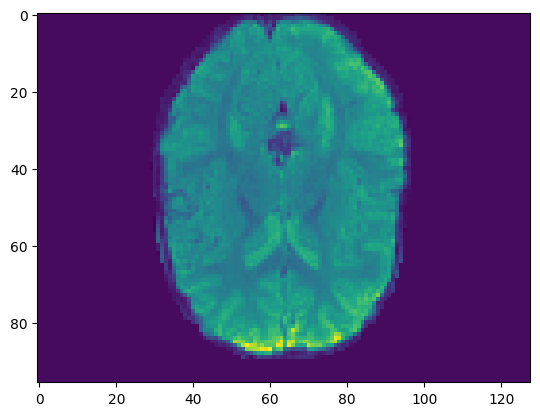

In [ ]:
#Let's do the reconstruction and see how close it is visually to the original
img_3drecon = pca.inverse_transform(img_3dcom)
img_3drecon = img_3drecon.reshape(-1, 96, 128)

plt.imshow(img_3drecon[10])

MSE:  180.98059977654398


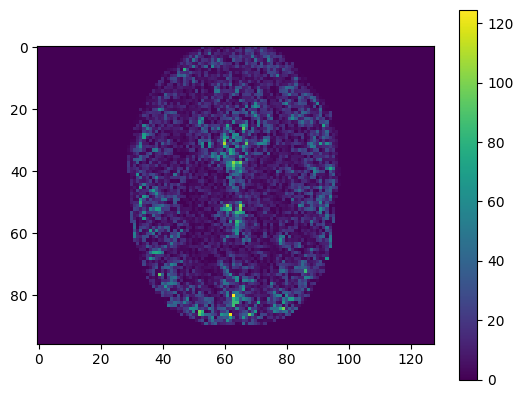

In [ ]:
#Error visualization
print('MSE: ', np.mean((img_3d[10]-img_3drecon[10])**2))

plt.imshow(np.abs(img_3d[10]-img_3drecon[10]))
plt.colorbar()

## Autoencoder

In [ ]:
digit_data = datasets.load_digits() #n_class: number of digit classes
digit_data.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [ ]:
import torch

In [ ]:
# convert into PyTorch tensors
X = digit_data['data']
X = torch.tensor(X, dtype=torch.float32)
X.shape

torch.Size([1797, 64])

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8

trainloader = DataLoader(X, batch_size=batch_size,
                                          shuffle=True)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(64, 10)
        self.fc2 = nn.Linear(10, 64)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

#create an instance of the model
net = Net()

In [ ]:
print(net)

Net(
  (fc1): Linear(in_features=64, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=64, bias=True)
)


In [ ]:
from torchsummary import summary
summary(net, (1,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 10]             650
            Linear-2                [-1, 1, 64]             704
Total params: 1,354
Trainable params: 1,354
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------


In [ ]:
#Mean squared loss
criterion = nn.MSELoss()

In [ ]:
#learning rate
lr = 0.001

#Adam
optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=1e-2)

In [ ]:
for epoch in range(50):  # loop over the dataset multiple times

    running_loss = 0.0

    for i, data in enumerate(trainloader):
        # get the inputs
        inputs = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 50 == 0:    # print every 10 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 5))
        running_loss = 0.0

print('Finished Training')

[1,     1] loss: 13.353
[1,    11] loss: 12.150
[1,    21] loss: 12.290
[1,    31] loss: 10.236
[1,    41] loss: 10.030
[1,    51] loss: 9.284
[1,    61] loss: 9.024
[1,    71] loss: 8.968
[1,    81] loss: 7.963
[1,    91] loss: 7.521
[1,   101] loss: 6.838
[1,   111] loss: 5.918
[1,   121] loss: 5.615
[1,   131] loss: 5.138
[1,   141] loss: 4.657
[1,   151] loss: 4.628
[1,   161] loss: 4.316
[1,   171] loss: 4.778
[1,   181] loss: 4.557
[1,   191] loss: 4.599
[1,   201] loss: 3.626
[1,   211] loss: 3.903
[1,   221] loss: 4.615
[2,     1] loss: 4.596
[2,    11] loss: 3.618
[2,    21] loss: 4.072
[2,    31] loss: 3.244
[2,    41] loss: 3.529
[2,    51] loss: 3.697
[2,    61] loss: 3.856
[2,    71] loss: 3.308
[2,    81] loss: 3.802
[2,    91] loss: 3.725
[2,   101] loss: 3.611
[2,   111] loss: 2.937
[2,   121] loss: 3.749
[2,   131] loss: 3.391
[2,   141] loss: 3.097
[2,   151] loss: 2.988
[2,   161] loss: 2.854
[2,   171] loss: 3.348
[2,   181] loss: 3.062
[2,   191] loss: 2.854
[2,   

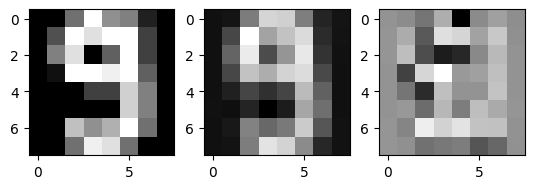

In [ ]:
#Visualize results

plt.subplot(131)
# Reshape the array for plotting
x = inputs.reshape(-1, 8, 8)
plt.imshow(x[0], 'gray')

plt.subplot(132)
x_hat = outputs.reshape(-1, 8, 8)
plt.imshow(x_hat[0].data.numpy(), 'gray')

plt.subplot(133)
plt.imshow(x[0]-x_hat[0].data.numpy(), 'gray')

## Try it with MNIST Dataset, each digit image is of 28x28

The dataset can be directly accessed via:    
`
dataset = datasets.MNIST(root = "./data",
                         train = True,
                         download = True,
                         transform = tensor_transform)
`